## **TRAINING**

In [ ]:
# --- 1. SETUP ---
!pip install -q transformers[torch] datasets evaluate accelerate underthesea
import torch
from datasets import load_dataset
from underthesea import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

# --- 2. LOAD & INSPECT DATA ---
dataset = load_dataset("vominhmanh/vihsd-explainable")

# Dynamically find text and label columns
possible_text_cols = ['free_text', 'text', 'sentence']
possible_label_cols = ['label_id', 'label']

TEXT_COL = next((c for c in possible_text_cols if c in dataset['train'].column_names), None)
LABEL_COL = next((c for c in possible_label_cols if c in dataset['train'].column_names), None)

print(f"Detected columns: Text='{TEXT_COL}', Label='{LABEL_COL}'")

# --- 3. PREPROCESSING (The 'NoneType' Fix) ---
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

def preprocess_function(examples):
    # Fix: Ensure every input is a string and not 'None'
    texts = [str(t) if t is not None else "" for t in examples[TEXT_COL]]
    # PhoBERT requires word segmentation (Học sinh -> Học_sinh)
    segmented_texts = [word_tokenize(t, format="text") for t in texts]
    return tokenizer(segmented_texts, padding="max_length", truncation=True, max_length=128)

# Clean nulls and tokenize for all splits
tokenized_dataset = dataset.filter(lambda x: x[TEXT_COL] is not None).map(preprocess_function, batched=True)

# Format for Trainer
tokenized_dataset = tokenized_dataset.rename_column(LABEL_COL, "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# --- 4. TRAINING SETUP (The 'eval_strategy' Fix) ---
model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base-v2", num_labels=3)
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

training_args = TrainingArguments(
    output_dir="./results",
    # Fix: In newer transformers, use eval_strategy instead of evaluation_strategy
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=torch.cuda.is_available() # Faster training on GPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"], # <--- Change "test" to "validation"
    compute_metrics=compute_metrics,
)

# --- 5. START ---
trainer.train()

Detected columns: Text='text', Label='label_id'


Filter:   0%|          | 0/24048 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2672 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6680 [00:00<?, ? examples/s]

Map:   0%|          | 0/24046 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4509, training_loss=0.3257973442640239, metrics={'train_runtime': 899.5192, 'train_samples_per_second': 80.196, 'train_steps_per_second': 5.013, 'total_flos': 4745118932015616.0, 'train_loss': 0.3257973442640239, 'epoch': 3.0})

## **EVALUATION**

In [ ]:
# Final unbiased evaluation after training is complete
results = trainer.evaluate(tokenized_dataset["test"])
print("Final Test Results:", results)

Final Test Results: {'eval_loss': 0.3975459933280945, 'eval_f1': 0.661321921961278, 'eval_runtime': 47.8423, 'eval_samples_per_second': 139.625, 'eval_steps_per_second': 17.453, 'epoch': 3.0}


## **REPORT**


--- Classification Report ---
              precision    recall  f1-score   support

       Clean       0.93      0.95      0.94      5548
   Offensive       0.51      0.37      0.43       444
        Hate       0.61      0.61      0.61       688

    accuracy                           0.88      6680
   macro avg       0.68      0.65      0.66      6680
weighted avg       0.87      0.88      0.87      6680



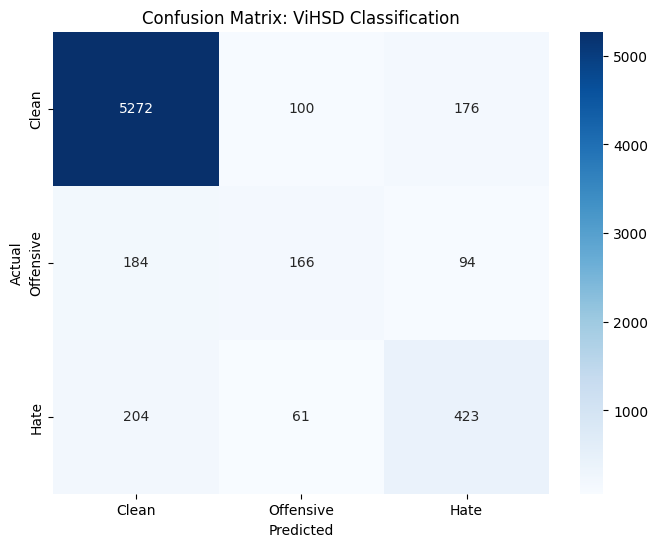

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get predictions from the test set
# (Ensure your tokenized_dataset has a "test" split)
predictions_output = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# 2. Define your labels (Based on ViHSD typical schema)
target_names = ["Clean", "Offensive", "Hate"]

# 3. Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))
# 4. Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: ViHSD Classification')
plt.show()

## **SAVE MODEL**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save model and tokenizer
model_path = "/content/drive/MyDrive/phobert_hate_speech_model"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model saved to: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/phobert_hate_speech_model


## **LOAD MODEL**

In [ ]:
# 1. Mount Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# 2. Define the path where you saved it
model_path = "/content/drive/MyDrive/phobert_hate_speech_model"

# 3. Load the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)

# 4. Load the Model
# It will automatically detect the architecture (PhoBERT) and the number of labels
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# 5. Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model and Tokenizer loaded successfully!")

Mounted at /content/drive


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and Tokenizer loaded successfully!


## **DEMO**

In [ ]:
def predict_hate_speech(text):
    # 1. Tokenize the input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)

    # 2. Move inputs to the same device as the model (GPU/CPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Get the model's output
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        outputs = model(**inputs)

    # 4. Convert logits to probabilities
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probabilities, dim=-1).item()

    # 5. Map the numeric ID to a label
    # Note: Adjust these labels based on your specific dataset classes!
    labels = {0: "Clean", 1: "Hate", 2:"Offensive"}
    result = labels.get(prediction, "Unknown")

    return result, probabilities[0][prediction].item()

# --- Interactive Test ---
test_text = "Bạn ngu vcl"
label, confidence = predict_hate_speech(test_text)

print(f"Text: {test_text}")
print(f"Result: {label} ({confidence*100:.2f}%)")

Text: Bạn ngu vcl
Result: Offensive (94.51%)
